# Matplotlib - Scatter Plots
___
- EG: `df.plot(kind='scatter')`
- These type of Plots are great at showing correlation between multiple Variables
- We are able to see how things like Median Salary correlate to the Count/Demand of a Skill in Job Postings
    - Spoiler alert, that's the Visualization that will be worked on in this lesson
    - Also, for the Insights of this, we will notice that Python will be up in the Top Right Corner, meaning it's not only a highly paid skill, but also has a high demand
    - This just shows you can get really good Insights out of these Types of Plots
- But as always, let's start with a simple example!
    - We will start by Creating this DataFrame filled with Fake Data
        - Starting of making a Dictionary with different **Keys** and **Values**
        - Inside of it, there's different job_skills, along with the made up Counts alongside their made up Pay
    - Then we Convert/Transform the Dictionary into a DataFrame
    - Then when it turns into a Dictionary, it can be Plotted!
        - Start by defining our `df` and Invoking the `.plot()` Function
        - Inside, Set the `kind='scatter'`
        - Providing the X Values as: `x='skill_count'`
        - Providing the Y Values as: `y='skill_pay'`

<Axes: xlabel='skill_count', ylabel='skill_pay'>

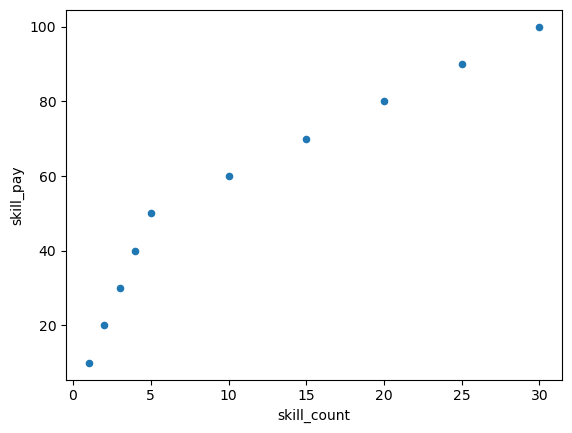

In [2]:
# Simple Scatter Plot Example
import pandas as pd

# Dictionary with Fake Data
data = {
    'job_skills': ['Python', 'SQL', 'Java', 'C++', 'C#', 'Javascript', 'HTML', 'CSS', 'PHP', 'Ruby'],
    'skill_count': [30, 25, 20, 15, 10, 5, 4, 3, 2, 1],
    'skill_pay': [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]
}

# Converting Dictionary to DataFrame
df = pd.DataFrame(data)

# Plotting the DataFrame
df.plot(kind='scatter', x='skill_count', y='skill_pay')

- Running the above, we have our Scatter Plot! Super simple to make and to see the Information
- Granted this Chart needs to be Cleaned up as it's missing Labels and such but the bones of it is there
- Most important thing to understand is that we are able to Plot things by their X and Y Coordinates according to the Skill

- Now, on to making the Scatter Visualization that was mentioned at the start of the Lesson:
    - We need to get our Data in a form, similar to what we provided above
        - Wherby, `skill_pay` and `skill_count` aggregated by each of those Skills
    - So what we need to do is Create a DataFrame with 3 Columns, `job_skills`, `median_salary` and `skill_count` and sorted in Descending Order by `skill_count`
        - `job_skills` will be the **Index** and for each of those Skills, we'd need to know what the `median_salary` and `skill_count` are
    - The purpose of this Format, we can use the `median_salary` as the Y Axis and the `skill_count` as the X Axis on the Scatter Plot
    - Because the Skill and Pay is very dependent on the Job Title, the DataFrame is going to be Filtered down to just **Data Analyst**
        - Let's get cracking on this by doing our usual Data Imports and then Filtering the Data Set down for only Data Analyst Jobs
        - Then we will Explode out the `job_skills` Column and assign it to it's own DataFrame

In [3]:
# Imports
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading the Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Cleaning the Data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

f:\Users\Neill\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Filtering and Replacing the Original DataFrame with only Data where the job_title is Data Analyst
df = df[df['job_title_short'] == 'Data Analyst']

# Exploding out the job_skills Column
df_exploded = df.explode('job_skills')

# Printing it out to show our work
df_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,power bi,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785717,Data Analyst,Data & Analytics Architect (w/m/x),"Erfurt, Jerman",melalui LinkedIn,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,NTT DATA DACH,azure,"{'cloud': ['aws', 'azure']}"
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sas,"{'analyst_tools': ['sas', 'excel'], 'programmi..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sas,"{'analyst_tools': ['sas', 'excel'], 'programmi..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sql,"{'analyst_tools': ['sas', 'excel'], 'programmi..."


- Next step is to do a Grouping... specifically for the `job_skills` we need to Group the job_skills in order to get:
    - The Count of these Skills
    - For the `salary_year_avg` Column, we need to Aggregate for each of those Skills to get the Median Salary back
- Using the Exploded DataFrame of `df_exploded`:
    - Using the `.groupby()` Function on it
        - Passing in `job_skills`
        - Then to see the Count, we use the `.size()` Function
    - Now, we not only want the Counts of these Skills, but also the Associated Median Salary
        - Since there's multiple Aggregation Functions happening, we need to invoke the `.agg()` Function
        - In here, we can pass in multiple Aggregations, in the case, `'size'` and `'median'`
            - But to do that, we are going to do something that we haven't done before
            - We will be using basically like a Dictionary in order to find Key and Values for how we want to do these different Aggregations
            - We will start with `skill_count`:
                - We want to name the New Column skill_count, so we start by invoking `skill_count`
                - Then set it Equal to a Tuple of 2 Variables, like so: `skill_count=('', '')` 
                - We will need to Pass in the Column we want to do the Aggregation on so: `'job_skills'`
                - Then Pass in the Aggregation Method that we want to do, in this case it's: `'count'`
                    - To Reiterate: `skill_count` is the New Column Name, then, using the `job_skills` Column to Perform a Count
            - We also want to do `median_salary`:
                - We want to name the New Column median_salary, so we start by invoking `median_salary`
                - Then set it Equal to a Tuple of 2 Variables, like so: `median_salary=('', '')` 
                - We will need to Pass in the Column we want to do the Aggregation on so: `'salary_year_avg'`
                - Then Pass in the Aggregation Method that we want to do, in this case it's: `'median'`
                    - To Reiterate: `median_salary` is the New Column Name, then, using the `salary_year_avg` Column to Perform Median
- After we do all that and Run it, we now have 2 New Columns Created called skill_count and median_salary side by side
- Now we Assign the DataFrame that we got back to a New Variable called `skill_stats`
    - This is so we can Sort the Values of it Properly, because right now it's out of Order, it's only in Alphabetical Order by the Names
    - We will want to Sort these Values by the `skill_count` Column in Descending Order
        - To do this we will start by:
            - Calling our Variable `skill_stats`
            - Invoking the `.sort_values()` Function
            - Passing in what Column we want to Sort by: `by='skill_count'`
            - Passing in that we want it in Descending Order by: `ascending=False`
            - Because we only want the Top 10 Values back, we can do this by invoking: `.head(10)`
    - This Returns our Top 10 `skill_counts` with the highest Values up at the Top!
- Setting all of this, equal to a Variable since it has everything Sorted correctly and Returning only the Values we want (Top 10)
    - Like always we just use: `skills_stats = skill_stats.sort_values(...)`

In [5]:
# Grouping by the Skills and Creating 2 New Columns of skill_count and median_salary showing the associated Values to those Skills
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

skills_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(10)

- Now that we have everything we need, the last thing we need to do, is to Plot it!
    - To do this:
        - Declare our Variable: `skills_stats`
        - Invoke our `.plot()` Function
        - Passing in the kind that we want as a Scatter: `kind='scatter'`
        - Passing in the X Axis Value as: `x='skill_count'`
        - Passing in the Y Axis Value as: `y='median_salary'`
    - Running this and we get our Scatter Plot with the Skills Plotted along with having the Counts on the X and Salary on the Y!
    - Now the final thing to do on these, as always is to clean it up!
        - Giving an X Axis Label using: `plt.xlabel('Count of Job Postings')`
        - Giving a Y Axis Label using: `plt.ylabel('Median Yearly Salary ($USD)')`
        - Giving a Title using: `plt.title('Salary vs. Count of Job Postings for Top 10 Skills')`
        - Running the following to Shrink it down and make sure everything fits: `plt.tight_layout()`
        - Get rid of that Memory Location/Generated Label above the Visual using: `plt.show()`

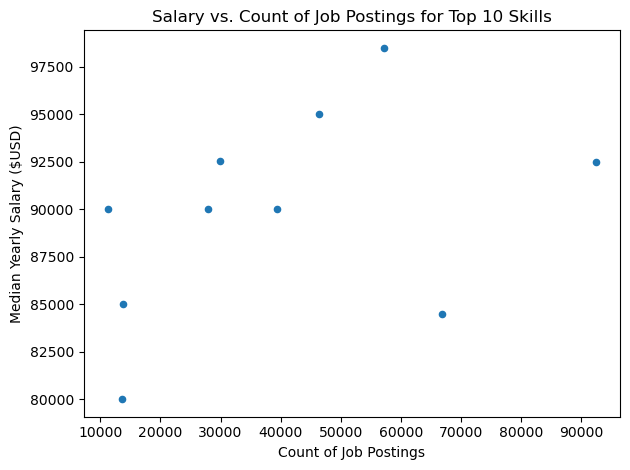

In [6]:
# Plotting our Top 10 Skills to see how Median Salary correlates to the Count/Demand of a Skill
skills_stats.plot(kind='scatter', x='skill_count', y='median_salary')

# Adding Cleanup to make the Visualization presentable
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()
plt.show()

- What we get back is a pretty cool Visual! We get back everything we need!
- Except... there is one major problem here
    - What are the Names Associated to all these Skills? We have no idea where anything is on the Graph... Which one is Python? Which one is SQL? We have no way of knowing...
    - Unfortunetly, Matplotlib doesn't make this easy to actually annotate this... (Eventually we will cover the Seaborn Library and it makes it a lot easier to do this)
    - For now, we will need to implement a workaround in order to get this to work and show these Label annotations on our Visual and luckily there's a Method for this!
        - `matplotlib.pyplot.text`
        - This comes from the PyPlot Module
        - It Adds the Text that you specify to the Axes at the Location X, Y in the Data Coordinates 
        - We provide 3 separate things: **X Value**, **Y Value**, **what we want to input**
    - Adding this into our Code like this:
        - Using our Matplotlib Library: `plt`
        - Invoking the Text Function of `.text()`
        - Passing in our 3 Arguments of X Value, Y Value and what Label we want to Display
            - For this example, we hard-coded these Values to show it working, picking the center of the Plot on X and Y and Adding in any String as a Label
            - Which, Value wise are `(50000, 90000, "Neil")`
        - Running this, we get the Label appearing in the Middle of the Plot

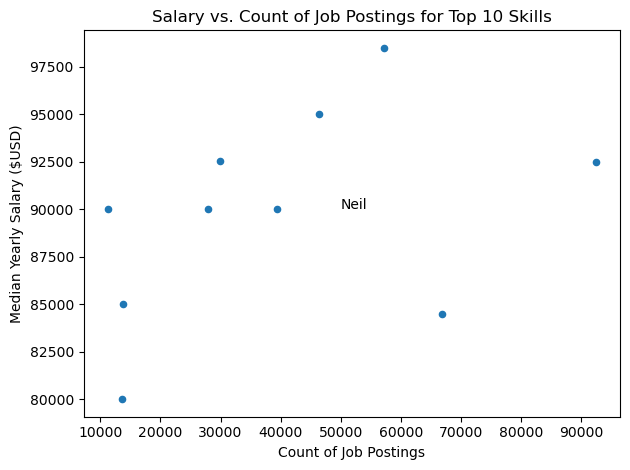

In [7]:
# Plotting our Top 10 Skills to see how Median Salary correlates to the Count/Demand of a Skill
skills_stats.plot(kind='scatter', x='skill_count', y='median_salary')

# Adding Cleanup to make the Visualization presentable
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()
# Adding in Label Annotations to the Visual to show the Skill Names
plt.text(50000, 90000, "Neil")
plt.show()

- Now, we could Add these in Manually... by looking at the Data finding the Corresponding Number to the Skill and hard-coding it with the correct Label, Passing in the X, Y and String Values
    - But that would be repetitive and would just be Repetetive Code over and over again doing the same thing and would be a lot of Manual Work too
    - Especially if any Values ever change, then it would all need to be Manually changed if that ever happens
- Or... we could use Python to actually do this for us!
- How would we do this? We could use a `for` Loop to Iterate through the 3 Column Dataset that we made!
    - Accessing the `job_skills` Column to get the Name which we would provide as the Text/String Value
    - For the X and Y Coordinates, we just provide the appropriate Value from the Column using something like `.iloc()` which we can Access the **Index** using the `enumerate()` Function!
    - Let's get into building it out!
        - Start with the usual for loop Syntax of: `for:`
        - Because we need the **Index** for this, we will name an Iterable of `i`
        - And because we want to grab the Skill Name Value inside the `job_skills` Column we'll need a Variable to hold that too, so we will use `txt` - We will do the Coordinates separately
        - Using the `in` Keyword since we will be looking inside of the `skills_stats` DataFrame
        - We will use the `enumarate()` Function so we can get the Skill Name from the `job_skills` Column. (Think of Enumerate as an incrementing Counter)
        - Passing in, our DataFrame of `skills_stats`
        - Then Invoking the `.index` Property on the DataFrame to get the Index Value of the DataFrame, which is actually `job_skills`
            - Remember, `job_skills` is not really a Column, it's the Index of the DataFrame. The only Columns are `skill_count` and `median_salary`
            - Verify this by using `print(skills_stats.index)` and `print(skills_stats.columns)`
        - And because Enumerate is a Counter that is storing how many iterations/Runs we do into `i` and because we are Accessing the **Index** of `job_skills`
        - Printing out to see what's going in using `print(i, txt)`
            - We get back 0 SQL, 1 Excel, 2 Python, 3 Tableau. We are Printing the Index and it's corresponding Counter Value or how many times it's Iterated through the List of Skills
            - We get the Index which is 0, 1, 2, 3, ... and the Value of the Index which is SQL, Excel, Python, ...
            - Now, the Counter acts as an Index in itself! So we basically have an Index for our Index and makes it super easy to access the corresponding Values of the DataFrame!
        - Altogether we have `for i, txt in enumerate(skills_stats.index):`
        - Next step is to Enumerate through the Plot Text Function, to do this:
            - Start by calling the Function: `plt.text()`
            - We will need to Provide the X, Y Values and the Text we want to Return as well
                - X Value: This is the Count of Job Postings or the Column: `skill_count`
                    - Start by Passing in the DataFrame of: `skills_stats` and telling it, what Column to access in the DataFrame which will be `[skill_count]`
                    - Now we are in the Column and can Access the Values, we need to specify the Specific Value from the Row we want to get. Do this by invoking the `.iloc[]` Method
                    - Because we are Passing an Index into here, we use the `[]`. The Value we Pass in is `i` since it has the Index to our Index from the `for` loop
                        - Altogether we have, `plt.text(skills_stats['skill_count'].iloc[i])`
                - Y Value: This is the Medaian Salary or the Column: `median_salary`
                    - Similarly, we are going to to the exact same thing as above, except it will be for the `median_salary` Column but we do the exact same thing
                    - Passing in the DataFrame of `skills_stats` and telling it to use Column `['median_salary']`, invoking `.iloc[]` and passing in the Index of `i`
                        - Altogether we have, `plt.text(skills_stats['skill_count'].iloc[i], skills_stats['median_salary'].iloc[i])`
                - Text Value: This is what we want to Return and is the Skill Value or the Index: `job_skills`
                    - Finally we will provide what we want to Return which is simply just `txt` since it will hold the Skill Value Name of SQL, Python, Excel and so on
                    - It will have the corresponding `job_skills` Value based on Iterating through the X and Y Values which is basesd on the Index/Counter of `i`
                    - The `txt` Variable is what holds the actual String Value that we want to Display
                        - Altogether we have, `plt.text(skills_stats['skill_count'].iloc[i], skills_stats['median_salary'].iloc[i], txt)`

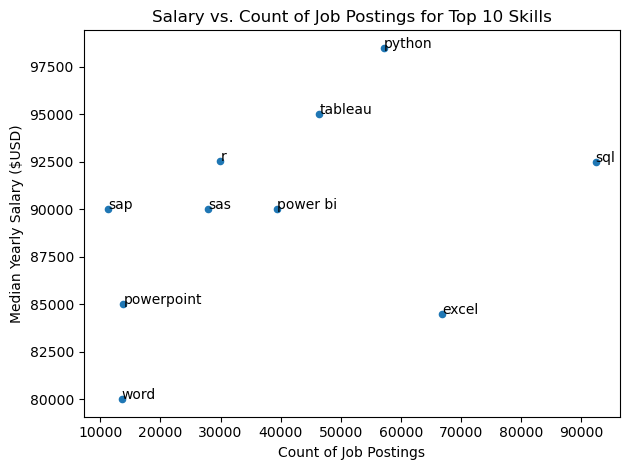

In [22]:
# Creating the Scatter Plot
skills_stats.plot(kind='scatter', x='skill_count', y='median_salary')

# Cleanup
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()

# For Loop to Iterate through the Data and Add in Label Annotations to the Visual to show the Skill Names
for i, txt in enumerate(skills_stats.index):
    plt.text(skills_stats['skill_count'].iloc[i], skills_stats['median_salary'].iloc[i], txt)

plt.show()

### Closing Remarks and Insights Learned
___
- Running this, we now have this Graph actually Labelled correctly with all the different Skill Name Values
    - Granted we had to do this special `for` Loop as a work around in order to get this... but we were able to do it nonetheless!
- This Visualization is one of the most Insightful ones we will make in the entire Course, since it shows us a lot of valuable information!
    - It shows based on Demand and Salary that:
        1. **Python**, **SQL** and **Tableau**, even **Excel** (even though it's a lower Salary), these are the most High Quality Skills to Focus on and learn for Data Analysis
        2. Not only are they Compensated really well but they are also high in demand!
        3. Important to Remember that this is for **Data Analysts**, so if we wanted to look at another Job Title, the DataFrame would need to be Re-Filtered for that!